# Superstore Profitability Audit

## Business Objective

This project analyzes sales, profitability, discounts, products, categories, sub-categories, and regions to identify the major drivers of profit loss.

### Key Business Questions

1. Is the business profitable overall?
2. How does discounting affect profitability?
3. Which categories and sub-categories generate the highest losses?
4. Which products contribute most to the losses?
5. Which regions are most affected?
6. What actions can the business take to improve profitability?

### Tools
- Python
- Pandas
- NumPy
- Matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/ispiermacbook/Downloads/Superstore/Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.shape

(9994, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Quarter"] = df["Order Date"].dt.quarter

## Data Preparation

The dataset was checked for missing values, duplicates, data types, and numerical inconsistencies. Date fields were converted to datetime format and additional time attributes were created for analysis.

In [9]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

profit_margin = total_profit / total_sales * 100

total_sales, total_profit, total_orders, total_customers, profit_margin

(np.float64(2297200.8603),
 np.float64(286397.0217),
 5009,
 793,
 np.float64(12.467217240315605))

In [10]:
overall_kpis = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Orders",
        "Customers",
        "Profit Margin"
    ],
    "Value": [
        total_sales,
        total_profit,
        total_orders,
        total_customers,
        profit_margin
    ]
})

overall_kpis

,Metric,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Orders,5.009000e+03
3,Customers,7.930000e+02
4,Profit Margin,1.246722e+01


In [11]:
category_profit = (
    df.groupby("Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

category_profit["Profit Margin"] = (
    category_profit["Profit"] /
    category_profit["Sales"] * 100
)

category_profit

,Category,Sales,Profit,Profit Margin
0,Furniture,741999.7953,18451.2728,2.486695
1,Office Supplies,719047.0320,122490.8008,17.035158
2,Technology,836154.0330,145454.9481,17.395712


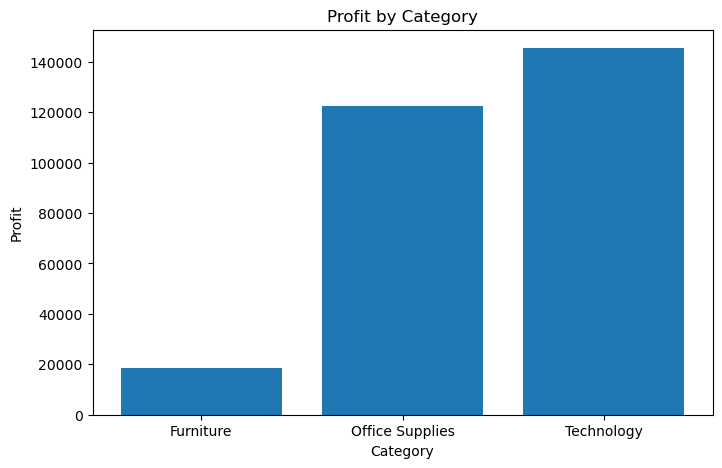

In [12]:
plt.figure(figsize=(8,5))

plt.bar(
    category_profit["Category"],
    category_profit["Profit"]
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

In [13]:
discount_analysis = (
    df.groupby("Discount")
      .agg(
          Orders=("Order ID", "count"),
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

discount_analysis["Profit Margin"] = (
    discount_analysis["Profit"] /
    discount_analysis["Sales"] * 100
)

discount_analysis

,Discount,Orders,Sales,Profit,Profit Margin
0,0.00,4798,1.087908e+06,320987.6032,29.505019
1,0.10,94,5.436935e+04,9029.1770,16.607108
2,0.15,52,2.755852e+04,1418.9915,5.149012
3,0.20,3657,7.645944e+05,90337.3060,11.815063
4,0.30,227,1.032267e+05,-10369.2774,-10.045155
5,0.32,27,1.449346e+04,-2391.1377,-16.498047
6,0.40,206,1.164178e+05,-23057.0504,-19.805437
7,0.45,11,5.484974e+03,-2493.1111,-45.453472
8,0.50,66,5.891854e+04,-20506.4281,-34.804712
9,0.60,138,6.644700e+03,-5944.6552,-89.464614


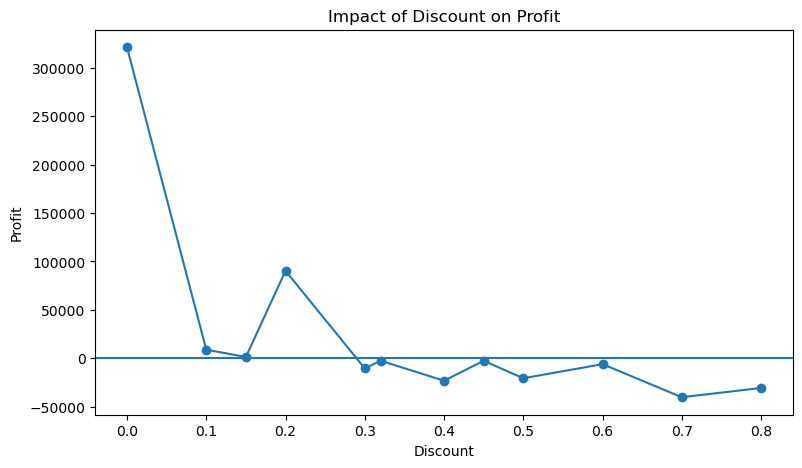

In [14]:
plt.figure(figsize=(9,5))

plt.plot(
    discount_analysis["Discount"],
    discount_analysis["Profit"],
    marker="o"
)

plt.axhline(0)

plt.title("Impact of Discount on Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

### Key Finding

Profitability deteriorates as discount levels increase. Higher discount levels generate increasingly negative profit, indicating that aggressive discounting can destroy margin rather than simply stimulate sales.

The analysis indicates that discounts of 40% and above are particularly damaging to profitability.

In [15]:
subcategory_analysis = (
    df.groupby("Sub-Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

subcategory_analysis["Profit Margin"] = (
    subcategory_analysis["Profit"] /
    subcategory_analysis["Sales"] * 100
)

subcategory_analysis = subcategory_analysis.sort_values(
    "Profit"
)

subcategory_analysis

,Sub-Category,Sales,Profit,Profit Margin
16,Tables,206965.5320,-17725.4811,-8.564460
4,Bookcases,114879.9963,-3472.5560,-3.022768
15,Supplies,46673.5380,-1189.0995,-2.547695
8,Fasteners,3024.2800,949.5182,31.396504
11,Machines,189238.6310,3384.7569,1.788618
10,Labels,12486.3120,5546.2540,44.418672
2,Art,27118.7920,6527.7870,24.071083
7,Envelopes,16476.4020,6964.1767,42.267582
9,Furnishings,91705.1640,13059.1436,14.240358
1,Appliances,107532.1610,18138.0054,16.867517


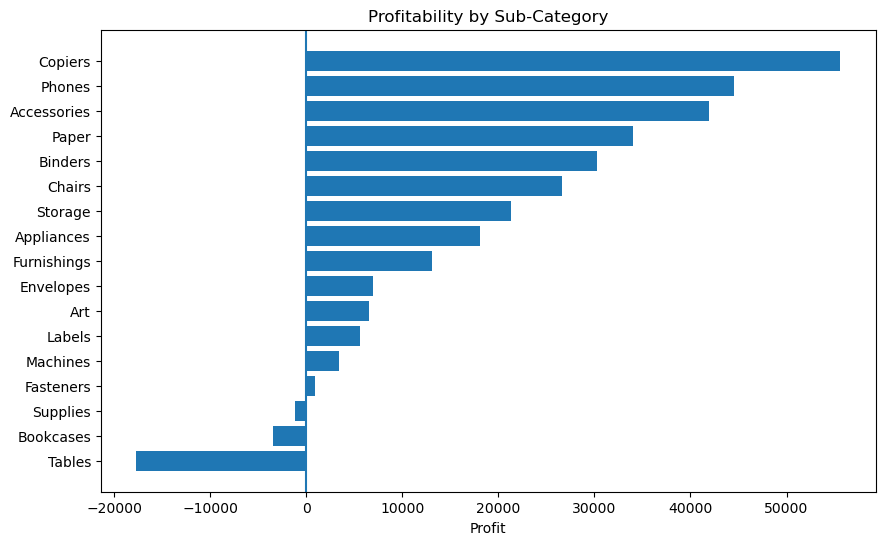

In [16]:
plt.figure(figsize=(10,6))

plt.barh(
    subcategory_analysis["Sub-Category"],
    subcategory_analysis["Profit"]
)

plt.axvline(0)

plt.title("Profitability by Sub-Category")
plt.xlabel("Profit")

plt.show()

In [17]:
subcategory_analysis.head(5)

,Sub-Category,Sales,Profit,Profit Margin
16,Tables,206965.5320,-17725.4811,-8.564460
4,Bookcases,114879.9963,-3472.5560,-3.022768
15,Supplies,46673.5380,-1189.0995,-2.547695
8,Fasteners,3024.2800,949.5182,31.396504
11,Machines,189238.6310,3384.7569,1.788618


### Key Finding

Losses are concentrated in specific sub-categories rather than being evenly distributed across the business.

These sub-categories should be reviewed for pricing, discounting, product mix, and promotional strategy.

In [18]:
product_analysis = (
    df.groupby("Product Name")
      .agg(
          Orders=("Order ID", "count"),
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Avg_Discount=("Discount", "mean")
      )
      .reset_index()
)

product_analysis["Profit Margin"] = (
    product_analysis["Profit"] /
    product_analysis["Sales"] * 100
)

product_analysis

,Product Name,Orders,Sales,Profit,Avg_Discount,Profit Margin
0,"""While you Were Out"" Message Book, One Form pe...",3,25.228,10.3880,0.133333,41.176471
1,"#10 Gummed Flap White Envelopes, 100/Box",4,41.300,16.7678,0.100000,40.600000
2,#10 Self-Seal White Envelopes,4,108.682,52.1230,0.050000,47.959184
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",7,488.904,223.1408,0.057143,45.641026
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",10,286.672,115.2806,0.080000,40.213415
...,...,...,...,...,...,...
1845,iKross Bluetooth Portable Keyboard + Cell Phon...,5,477.660,115.6440,0.080000,24.210526
1846,iOttie HLCRIO102 Car Mount,5,215.892,-11.9940,0.160000,-5.555556
1847,iOttie XL Car Mount,2,223.888,-50.3748,0.200000,-22.500000
1848,invisibleSHIELD by ZAGG Smudge-Free Screen Pro...,7,442.554,171.2648,0.171429,38.699187


In [19]:
top_loss_products = (
    product_analysis
    .sort_values("Profit")
    .head(10)
)

top_loss_products

,Product Name,Orders,Sales,Profit,Avg_Discount,Profit Margin
475,Cubify CubeX 3D Printer Double Head Print,3,11099.963,-8879.9704,0.533333,-80.000000
985,Lexmark MX611dhe Monochrome Laser Printer,4,16829.901,-4589.9730,0.400000,-27.272727
476,Cubify CubeX 3D Printer Triple Head Print,1,7999.980,-3839.9904,0.500000,-48.000000
425,Chromcraft Bull-Nose Wood Oval Conference Tabl...,5,9917.640,-2876.1156,0.280000,-29.000000
376,Bush Advantage Collection Racetrack Conference...,7,9544.725,-1934.3976,0.350000,-20.266667
683,GBC DocuBind P400 Electric Binding System,6,17965.068,-1878.1662,0.450000,-10.454545
444,Cisco TelePresence System EX90 Videoconferenci...,1,22638.480,-1811.0784,0.500000,-8.000000
1043,Martin Yale Chadless Opener Electric Letter Op...,6,16656.200,-1299.1836,0.100000,-7.800000
285,Balt Solid Wood Round Tables,4,6518.754,-1201.0581,0.200000,-18.424658
364,BoxOffice By Design Rectangular and Half-Moon ...,3,1706.250,-1148.4375,0.483333,-67.307692


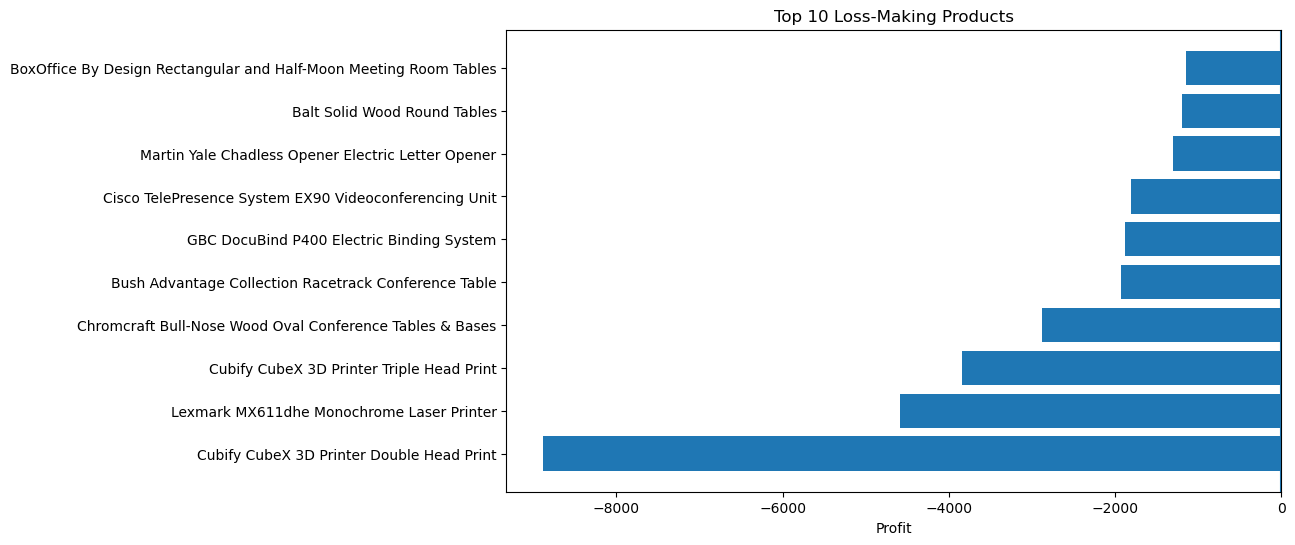

In [20]:
plt.figure(figsize=(10,6))

plt.barh(
    top_loss_products["Product Name"],
    top_loss_products["Profit"]
)

plt.axvline(0)

plt.title("Top 10 Loss-Making Products")
plt.xlabel("Profit")

plt.show()

In [21]:
discount_risk = df[df["Profit"] < 0].copy()

discount_risk["Loss_Contribution"] = (
    discount_risk["Profit"].abs()
)

discount_risk.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Quarter,Loss_Contribution
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,4,383.0310
14,15,US-2015-118983,2015-11-22,11/26/2015,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,5,0.80,-123.8580,2015,11,4,123.8580
15,16,US-2015-118983,2015-11-22,11/26/2015,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,Binders,Storex DuraTech Recycled Plastic Frosted Binders,2.5440,3,0.80,-3.8160,2015,11,4,3.8160
23,24,US-2017-156909,2017-07-16,7/18/2017,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196,2017,7,3,1.0196
27,28,US-2015-150630,2015-09-17,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522,2015,9,3,1665.0522


In [22]:
top_risk_products = (
    discount_risk
    .groupby(
        ["Region", "Category", "Sub-Category", "Product Name"]
    )
    .agg(
        Orders=("Order ID", "count"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Avg_Discount=("Discount", "mean"),
        Loss=("Loss_Contribution", "sum")
    )
    .reset_index()
)

top_risk_products["Profit Margin"] = (
    top_risk_products["Profit"] /
    top_risk_products["Sales"] * 100
)

top_risk_products = top_risk_products.sort_values(
    "Loss",
    ascending=False
)

top_risk_products.head(10)

,Region,Category,Sub-Category,Product Name,Orders,Sales,Profit,Avg_Discount,Loss,Profit Margin
782,East,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,2,6299.979,-9239.9692,0.7,9239.9692,-146.666667
319,Central,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,2,3266.376,-5552.8392,0.8,5552.8392,-170.000000
1054,South,Technology,Machines,Cubify CubeX 3D Printer Triple Head Print,1,7999.980,-3839.9904,0.5,3839.9904,-48.000000
313,Central,Office Supplies,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,2,2287.782,-3431.6730,0.8,3431.6730,-150.000000
1248,West,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,1,2549.985,-3399.9800,0.7,3399.9800,-133.333333
351,Central,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,1,1889.990,-2929.4845,0.8,2929.4845,-155.000000
908,South,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,2,6611.760,-2865.0960,0.4,2865.0960,-43.333333
952,South,Office Supplies,Binders,GBC DocuBind TL300 Electric Binding System,2,2960.067,-2269.3847,0.7,2269.3847,-76.666667
953,South,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,2,2967.822,-1978.5480,0.7,1978.5480,-66.666667
657,East,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,3,2967.822,-1978.5480,0.7,1978.5480,-66.666667


In [23]:
total_discount_loss = top_risk_products["Loss"].sum()

top_risk_products["Loss_Contribution_%"] = (
    top_risk_products["Loss"] /
    total_discount_loss * 100
)

top_risk_products["Cumulative_Loss_%"] = (
    top_risk_products["Loss_Contribution_%"].cumsum()
)

top_risk_products.head(10)

,Region,Category,Sub-Category,Product Name,Orders,Sales,Profit,Avg_Discount,Loss,Profit Margin,Loss_Contribution_%,Cumulative_Loss_%
782,East,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,2,6299.979,-9239.9692,0.7,9239.9692,-146.666667,5.918077,5.918077
319,Central,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,2,3266.376,-5552.8392,0.8,5552.8392,-170.000000,3.556519,9.474596
1054,South,Technology,Machines,Cubify CubeX 3D Printer Triple Head Print,1,7999.980,-3839.9904,0.5,3839.9904,-48.000000,2.459462,11.934058
313,Central,Office Supplies,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,2,2287.782,-3431.6730,0.8,3431.6730,-150.000000,2.197941,14.131999
1248,West,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,1,2549.985,-3399.9800,0.7,3399.9800,-133.333333,2.177642,16.309641
351,Central,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,1,1889.990,-2929.4845,0.8,2929.4845,-155.000000,1.876296,18.185936
908,South,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,2,6611.760,-2865.0960,0.4,2865.0960,-43.333333,1.835056,20.020992
952,South,Office Supplies,Binders,GBC DocuBind TL300 Electric Binding System,2,2960.067,-2269.3847,0.7,2269.3847,-76.666667,1.453511,21.474503
953,South,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,2,2967.822,-1978.5480,0.7,1978.5480,-66.666667,1.267234,22.741736
657,East,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,3,2967.822,-1978.5480,0.7,1978.5480,-66.666667,1.267234,24.008970


In [24]:
first_above_80 = (
    top_risk_products[
        top_risk_products["Cumulative_Loss_%"] > 80
    ]
    .head(1)
)

first_above_80

,Region,Category,Sub-Category,Product Name,Orders,Sales,Profit,Avg_Discount,Loss,Profit Margin,Loss_Contribution_%,Cumulative_Loss_%
568,East,Furniture,Tables,Bevis Rectangular Conference Tables,1,350.352,-140.1408,0.4,140.1408,-40.0,0.089758,80.000091


### Pareto Finding

Approximately 179 product-level records are required to reach 80% of the total discount-related loss.

This indicates that the loss problem is broadly distributed across the product portfolio rather than being caused by only a handful of products.

Therefore, the business should address the underlying discounting strategy instead of focusing exclusively on individual products.

In [26]:
region_analysis = (
    df.groupby("Region")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

region_analysis["Profit Margin"] = (
    region_analysis["Profit"] /
    region_analysis["Sales"] * 100
)

region_analysis

,Region,Sales,Profit,Profit Margin
0,Central,501239.8908,39706.3625,7.921629
1,East,678781.2400,91522.7800,13.483399
2,South,391721.9050,46749.4303,11.934342
3,West,725457.8245,108418.4489,14.944831


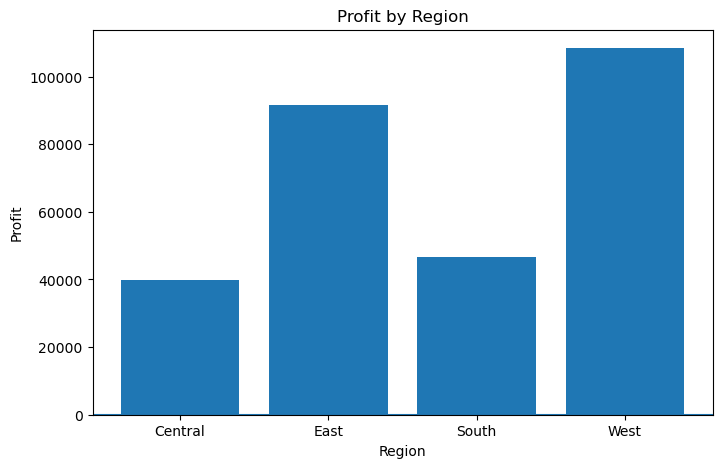

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    region_analysis["Region"],
    region_analysis["Profit"]
)

plt.axhline(0)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

# Business Insights

### 1. Discounting is a major profitability driver
Profitability declines sharply as discount levels increase, with aggressive discounts producing substantial losses.

### 2. High discounts require tighter controls
Discount levels of 40% and above are associated with significant negative profitability and should require stronger pricing controls.

### 3. Losses are concentrated in specific product areas
Several products and sub-categories repeatedly generate negative profit and should be reviewed for pricing and discount strategy.

### 4. Discount-related losses are broadly distributed
Approximately 179 product-region combinations account for 80% of discount-related losses, indicating a systemic rather than isolated problem.

### 5. Regional performance differs
Profitability varies across regions, suggesting that discount policies and product mix should also be evaluated geographically.

# Business Recommendations

### 1. Introduce discount thresholds
Require approval for discounts above a defined threshold, particularly discounts of 40% or more.

### 2. Review loss-making products
Investigate products with consistently negative profit and high discount rates.

### 3. Optimize product-level pricing
Use historical margin performance to establish minimum profitable selling prices.

### 4. Review sub-category strategy
Focus corrective action on sub-categories with persistent negative profitability.

### 5. Monitor discount profitability regularly
Create a dashboard that tracks discount level, sales, profit, margin, and loss contribution.

### 6. Shift from revenue-focused to margin-focused decisions
High sales should not automatically be considered successful if those sales generate negative profit.

# Executive Summary

The Superstore profitability audit identifies discounting as a major driver of profit erosion.

While discounts can support sales volume, aggressive discounting is associated with substantial negative margins. Losses are also distributed across a broad range of products and product-region combinations, indicating that the issue requires a systematic pricing and discount-management approach.

The analysis recommends tighter discount controls, product-level profitability reviews, sub-category optimization, and continuous margin monitoring.

## Business Goal

The objective is not simply to increase sales, but to increase **profitable sales**.